In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

from backtest import portfolio_daily_returns, performance_metrics

adj_close = pd.read_csv('../data/processed/adj_close_combined.csv', index_col='Date', parse_dates=True)
returns = adj_close.pct_change().dropna()

with open('../data/processed/portfolio_weights.json') as f:
    portfolio_data = json.load(f)

strategy_weights = portfolio_data['weights_max_sharpe']
print("Strategy weights:", strategy_weights)

Strategy weights: {'TSLA': 0.0, 'BND': -1e-16, 'SPY': 1.0}


Backtest window and benchmark

In [2]:
backtest_start = '2025-01-01'
backtest_end = '2026-06-30'
bt_returns = returns.loc[backtest_start:backtest_end]

benchmark_weights = {'TSLA': 0.0, 'BND': 0.40, 'SPY': 0.60}

Simulate both portfolios

In [3]:
strategy_daily = portfolio_daily_returns(bt_returns, strategy_weights)
benchmark_daily = portfolio_daily_returns(bt_returns, benchmark_weights)

strategy_cumulative = (1 + strategy_daily).cumprod()
benchmark_cumulative = (1 + benchmark_daily).cumprod()

Plot cumulative returns

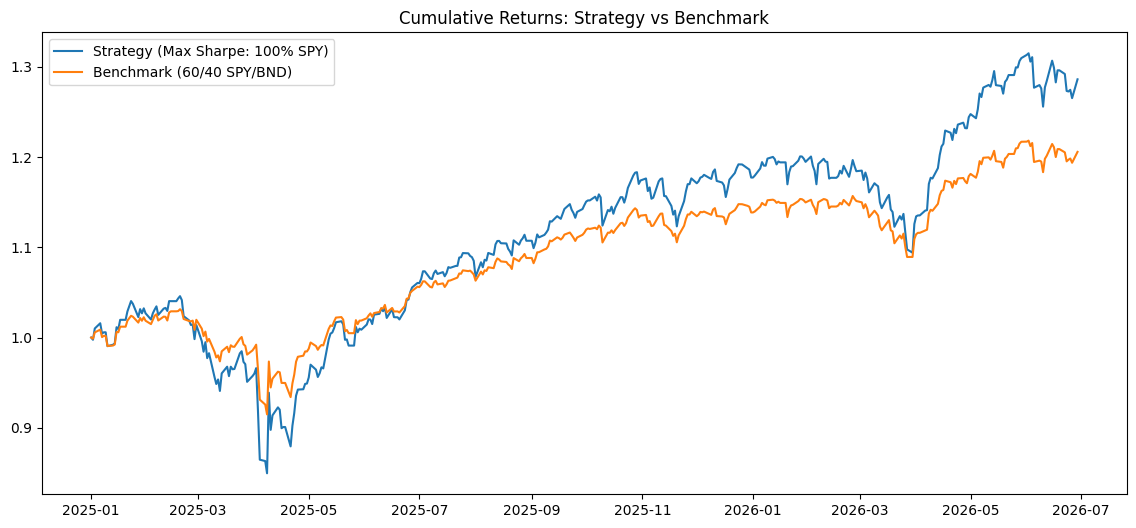

In [4]:
plt.figure(figsize=(14, 6))
plt.plot(strategy_cumulative.index, strategy_cumulative.values, label='Strategy (Max Sharpe: 100% SPY)')
plt.plot(benchmark_cumulative.index, benchmark_cumulative.values, label='Benchmark (60/40 SPY/BND)')
plt.title('Cumulative Returns: Strategy vs Benchmark')
plt.legend()
plt.savefig('../data/processed/backtest_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

Performance metrics

In [5]:
results = pd.DataFrame({
    'Strategy': performance_metrics(strategy_daily),
    'Benchmark': performance_metrics(benchmark_daily),
}).T
print(results)

           total_return  annualized_return  sharpe_ratio  max_drawdown
Strategy       0.285978           0.176964      0.902786     -0.187552
Benchmark      0.205615           0.128777      0.978728     -0.112888


## Backtest Conclusion

Over the 2025-01 to 2026-06 backtesting window, the strategy portfolio 
(100% SPY, per Task 4's Max Sharpe recommendation) delivered a total return 
of 28.60% versus the benchmark's (60% SPY / 40% BND) 20.56% — outperforming 
by roughly 8 percentage points in absolute terms, with an annualized return 
of 17.70% versus 12.88%.

However, this outperformance came with meaningfully higher risk. The 
strategy's maximum drawdown was -18.76%, versus just -11.29% for the 
benchmark — nearly 7.5 percentage points deeper. Correspondingly, the 
strategy's Sharpe Ratio (0.903) was actually *lower* than the benchmark's 
(0.979), meaning that on a risk-adjusted basis, the 60/40 benchmark was the 
more efficient portfolio over this specific period, even though it produced 
a smaller absolute return. This is a direct consequence of the strategy 
being 100% equities (SPY) with no bond allocation, while the benchmark's 
40% BND weighting cushioned its drawdowns — most visibly during the sharp 
dip in April 2025, where the strategy fell further than the benchmark before 
both recovered.

This result should be read carefully rather than as a simple "win" for the 
model-driven approach. It shows that the strategy took on more risk and was 
compensated with more return in this particular window — but did not do so 
more *efficiently* than the passive benchmark. Whether that trade-off is 
desirable depends entirely on the client's risk tolerance, which is 
precisely the kind of judgment GMF's advisory role is meant to provide 
alongside the quantitative output, not replace.

Several limitations temper any stronger conclusion:

1. **Single backtest window** — only one 18-month period was tested, with 
   no walk-forward validation across multiple historical windows; a 
   different period (e.g., one without a strong equity rally) could easily 
   reverse this result.
2. **No rebalancing or transaction costs** — both portfolios hold static 
   initial weights for the full period; real-world implementation would 
   incur trading costs and require periodic rebalancing, reducing net returns.
3. **Point-forecast dependency** — the strategy's 100% SPY allocation stems 
   directly from one LSTM run's negative TSLA forecast (Task 3); a different 
   model, training seed, or updated data could shift this allocation 
   materially, as discussed in Task 4.
4. **Backtest/test-period overlap** — this window overlaps with Task 2's 
   test period, so the LSTM's forecast behavior here is already partially 
   known; a genuine forward test would require entirely unseen future data.

Consistent with the Efficient Market Hypothesis framing established earlier 
in this report, this result is best treated as one encouraging but 
inconclusive data point — a reasonable basis for further testing across 
more market regimes, not a validated production strategy.